### 1. One-way reaction
$$
A \overset{k}\rightarrow B
$$
$$
\frac{d[A]}{dt} = - k[A]
$$
$$
\frac{d[B]}{dt} = k[B]
$$

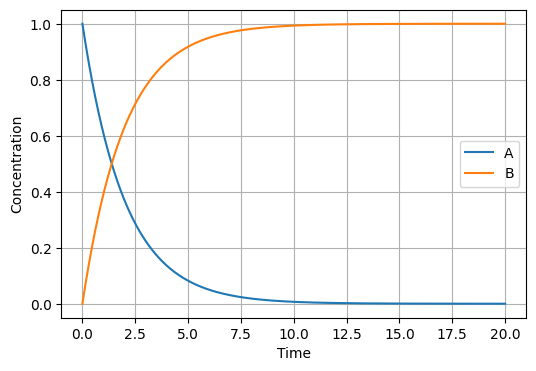

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def reaction(t, y, k):
    A, B = y

    dA = -k * A
    dB =  k * A

    return [dA, dB]

A0 = 1.0
B0 = 0.0

y0 = [A0, B0]

k = 0.5

t_span = (0, 20)

t_eval = np.linspace(*t_span, 400)

solution = solve_ivp(
    reaction,
    t_span,
    y0,
    args=(k,),
    t_eval=t_eval
)

plt.figure(figsize=(6,4))

plt.plot(solution.t, solution.y[0], label="A")
plt.plot(solution.t, solution.y[1], label="B")

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)

plt.show()

### 2. Reversible reaction
$$
A \overset{k_1}{\underset{k_2}{\rightleftharpoons}} B
$$
$$
\frac{d[A]}{dt} = k_2[B] - k_1[A]
$$
$$
\frac{d[B]}{dt} = k_1[A] - k_2[B]
$$
$$
\frac{d}{dt}([A]+[B]) = 0
$$

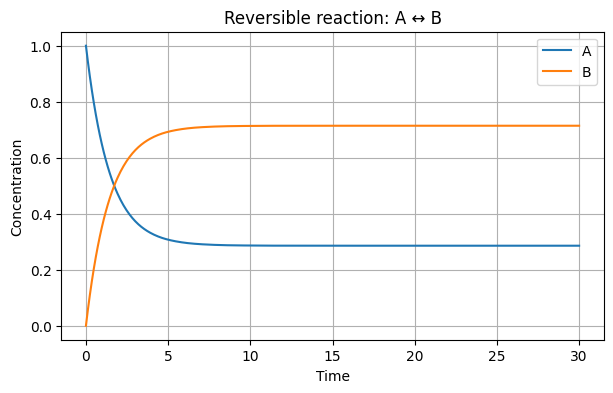

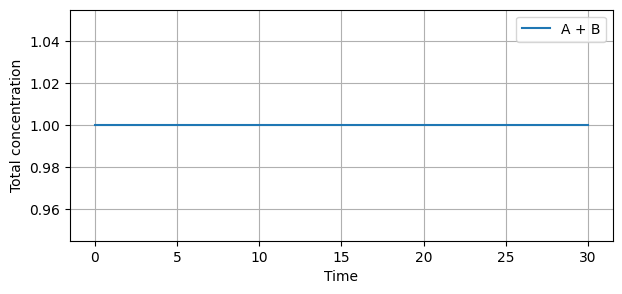

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def reversible_reaction(t, y, k1, k2):
    """
    Reversible reaction:

        A <-> B

    Parameters
    ----------
    y : list
        [A, B]
    k1 : float
        Forward rate constant
    k2 : float
        Reverse rate constant
    """

    A, B = y

    dA = -k1*A + k2*B
    dB =  k1*A - k2*B

    return [dA, dB]

# Rate constants
k1 = 0.50
k2 = 0.20

# Initial concentrations
A0 = 1.0
B0 = 0.0

y0 = [A0, B0]

t_start = 0
t_end = 30

t_eval = np.linspace(t_start, t_end, 500)

solution = solve_ivp(
    reversible_reaction,
    (t_start, t_end),
    y0,
    args=(k1, k2),
    t_eval=t_eval
)

t = solution.t
A = solution.y[0]
B = solution.y[1]

plt.figure(figsize=(7,4))

plt.plot(t, A, label='A')
plt.plot(t, B, label='B')

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Reversible reaction: A ↔ B")

plt.grid(True)
plt.legend()

plt.show()


plt.figure(figsize=(7,3))

plt.plot(t, A + B, label="A + B")

plt.xlabel("Time")
plt.ylabel("Total concentration")

plt.grid(True)
plt.legend()

plt.show()

Equilibrium point:
$$
\frac{[B]}{[A]} = \frac{k_1}{k_2} = \frac{0.5}{0.2} = 2.5
$$
$$
[A]_{eq} = \frac{k_2}{k_1 + k_2} = \frac{0.2}{0.7} \approx 0.286
$$
$$
[B]_{eq} = \frac{k_1}{k_1 + k_2} = \frac{0.5}{0.7} \approx 0.714
$$

### 3. Three-way equilibrium
$$
A \overset{k_{AB}}{\underset{k_{BA}}{\rightleftharpoons}} B \overset{k_{BC}}{\underset{k_{CB}}{\rightleftharpoons}} C
$$
$$
\frac{d[A]}{dt} = k_{BA}[B] - k_{AB}[A]
$$
$$
\frac{d[B]}{dt} = k_{AB}[A] + k_{CB}[C] - k_{BA}[B] - k_{BC}[B]
$$
$$
\frac{d[C]}{dt} = k_{BC}[B] - k_{CB}[C]
$$
$$
\frac{d}{dt}([A] + [B] + [C]) = 0
$$

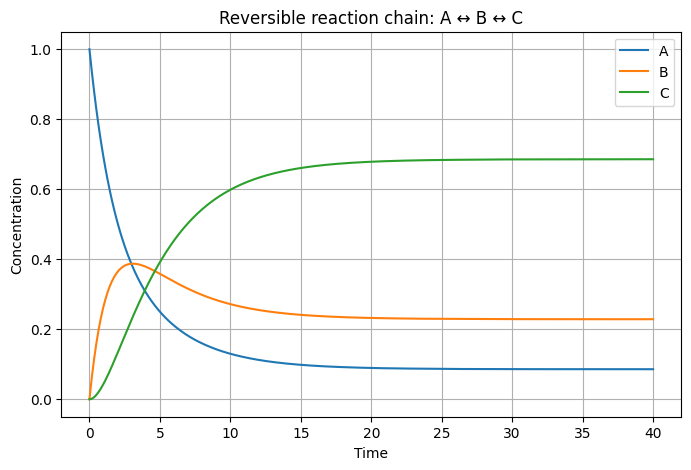

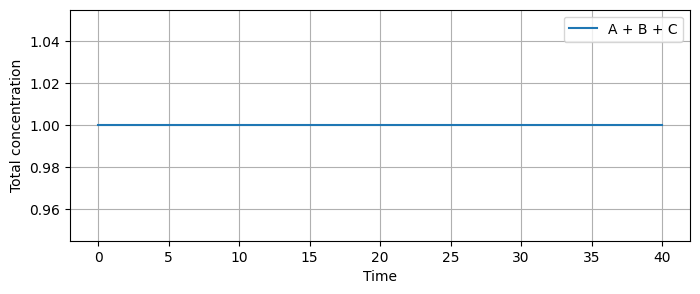

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def linear_reaction_system(t, y,
                           k_AB, k_BA,
                           k_BC, k_CB):

    A, B, C = y

    dA = -k_AB*A + k_BA*B

    dB = (
         k_AB*A
        -k_BA*B
        -k_BC*B
        +k_CB*C
    )

    dC = k_BC*B - k_CB*C

    return [dA, dB, dC]

k_AB = 0.40
k_BA = 0.15

k_BC = 0.30
k_CB = 0.10

k_AB = 0.40
k_BA = 0.15

k_BC = 0.30
k_CB = 0.10

A0 = 1.0
B0 = 0.0
C0 = 0.0

y0 = [A0, B0, C0]

t_span = (0, 40)

t_eval = np.linspace(*t_span, 500)

solution = solve_ivp(
    linear_reaction_system,
    t_span,
    y0,
    args=(k_AB, k_BA,
          k_BC, k_CB),
    t_eval=t_eval
)

t = solution.t

A = solution.y[0]
B = solution.y[1]
C = solution.y[2]


plt.figure(figsize=(8,5))

plt.plot(t, A, label="A")
plt.plot(t, B, label="B")
plt.plot(t, C, label="C")

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Reversible reaction chain: A ↔ B ↔ C")

plt.grid(True)
plt.legend()

plt.show()


plt.figure(figsize=(8,3))

plt.plot(t, A + B + C, label="A + B + C")

plt.xlabel("Time")
plt.ylabel("Total concentration")

plt.grid(True)
plt.legend()

plt.show()



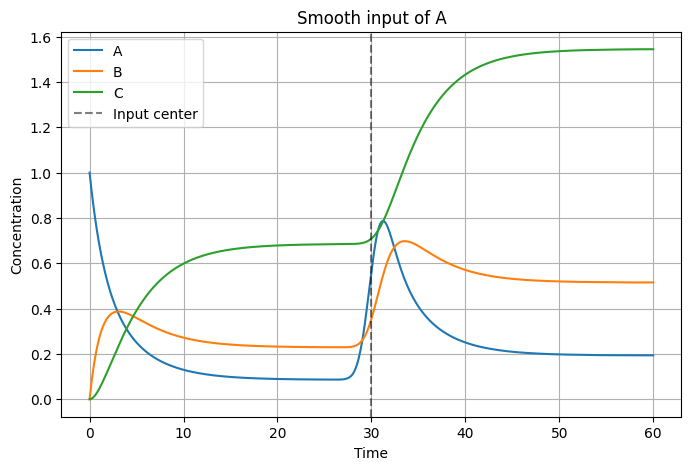

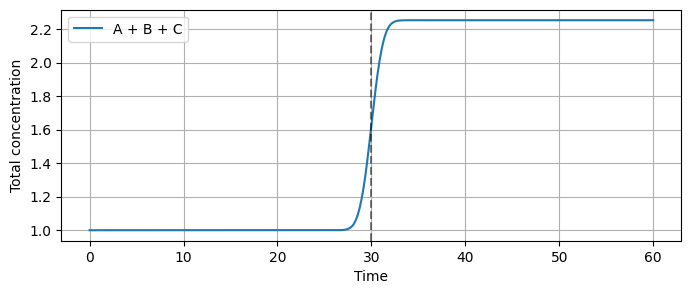

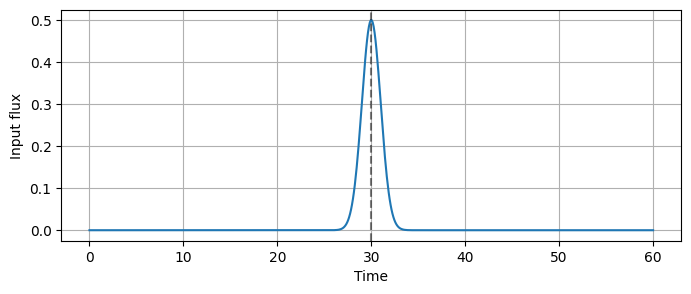

In [22]:
def input_flux(t, center=30, width=1.0, amplitude=0.5):
    """
    Gaussian pulse adding material to A.
    """
    return amplitude * np.exp(-0.5*((t-center)/width)**2)


def linear_reaction_system_input(t, y,
                                 k_AB, k_BA,
                                 k_BC, k_CB):

    A, B, C = y

    # External input into A
    I = input_flux(t)

    dA = -k_AB*A + k_BA*B + I

    dB = (
         k_AB*A
        -k_BA*B
        -k_BC*B
        +k_CB*C
    )

    dC = (
         k_BC*B
        -k_CB*C
    )

    return [dA, dB, dC]


# ---- Run a single simulation ----

t = np.linspace(0, 60, 600)

solution = solve_ivp(
    linear_reaction_system_input,
    (0, 60),
    y0,
    args=(k_AB, k_BA, k_BC, k_CB),
    t_eval=t
)

A = solution.y[0]
B = solution.y[1]
C = solution.y[2]


# ---- Plot concentrations ----

plt.figure(figsize=(8,5))

plt.plot(t, A, label="A")
plt.plot(t, B, label="B")
plt.plot(t, C, label="C")

plt.axvline(30, color='k', linestyle='--', alpha=0.5, label='Input center')

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Smooth input of A")

plt.grid(True)
plt.legend()

plt.show()


# ---- Plot total mass ----

plt.figure(figsize=(8,3))

plt.plot(t, A + B + C, label="A + B + C")

plt.axvline(30, color='k', linestyle='--', alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Total concentration")

plt.grid(True)
plt.legend()

plt.show()


# ---- Plot the input itself ----

I = input_flux(t)

plt.figure(figsize=(8,3))

plt.plot(t, I)

plt.axvline(30, color='k', linestyle='--', alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Input flux")

plt.grid(True)

plt.show()

### Michaelis-Menten mechanism (full mass-action)

The reaction network is

$$
E + S
\overset{k_1}{\underset{k_{-1}}{\rightleftharpoons}}
ES
\overset{k_2}{\rightarrow}
E + P
$$

where

- $E$ = enzyme
- $S$ = substrate
- $ES$ = enzyme-substrate complex
- $P$ = product

The reaction rates are

$$
v_1 = k_1ES
$$

$$
v_{-1} = k_{-1}ES
$$

$$
v_2 = k_2ES
$$

The governing differential equations are

$$
\frac{dS}{dt}
=
-k_1ES
+
k_{-1}ES
$$

$$
\frac{dE}{dt}
=
-k_1ES
+
(k_{-1}+k_2)ES
$$

$$
\frac{dES}{dt}
=
k_1ES
-
(k_{-1}+k_2)ES
$$

$$
\frac{dP}{dt}
=
k_2ES
$$

Two conservation laws hold:

$$
E + ES = \mathrm{constant}
$$

and

$$
S + ES + P = \mathrm{constant}.
$$

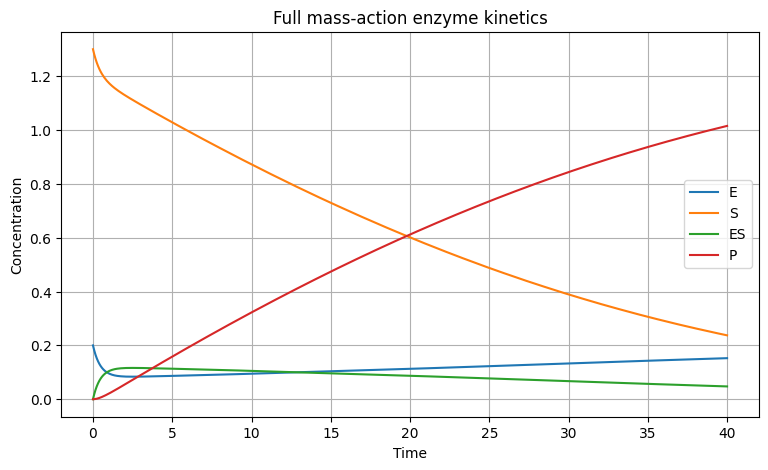

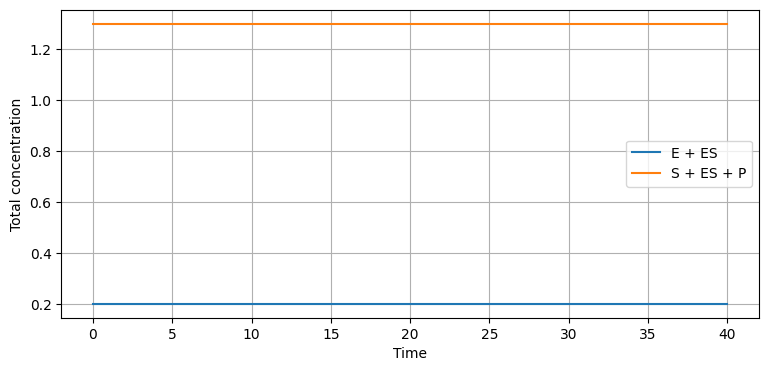

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def enzyme_system(t, y, k1, km1, k2):
    """
    Full mass-action enzyme kinetics.

    E + S <-> ES -> E + P
    """

    E, S, ES, P = y

    # Reaction rates
    v1  = k1 * E * S
    vm1 = km1 * ES
    v2  = k2 * ES

    dE  = -v1 + vm1 + v2
    dS  = -v1 + vm1
    dES =  v1 - vm1 - v2
    dP  =  v2

    return [dE, dS, dES, dP]

k1  = 1.0
km1 = 0.5
k2  = 0.3

E0  = 0.20
S0  = 1.30
ES0 = 0.00
P0  = 0.00

y0 = [E0, S0, ES0, P0]

t = np.linspace(0, 40, 500)

solution = solve_ivp(
    enzyme_system,
    (0, 40),
    y0,
    args=(k1, km1, k2),
    t_eval=t
)

E  = solution.y[0]
S  = solution.y[1]
ES = solution.y[2]
P  = solution.y[3]

plt.figure(figsize=(9,5))

plt.plot(t, E,  label="E")
plt.plot(t, S,  label="S")
plt.plot(t, ES, label="ES")
plt.plot(t, P,  label="P")

plt.xlabel("Time")
plt.ylabel("Concentration")

plt.title("Full mass-action enzyme kinetics")

plt.grid(True)
plt.legend()

plt.show()

plt.figure(figsize=(9,4))

plt.plot(t, E + ES, label="E + ES")
plt.plot(t, S + ES + P, label="S + ES + P")

plt.xlabel("Time")
plt.ylabel("Total concentration")

plt.grid(True)
plt.legend()

plt.show()

### Michaelis-Menten kinetics

The overall reaction is

$$
S \overset{v}{\longrightarrow} P
$$

where the reaction rate is assumed to follow the Michaelis-Menten equation

$$
v =
\frac{V_{\max}S}{K_m + S}.
$$

Here,

- $S$ = substrate concentration
- $P$ = product concentration
- $V_{\max}$ = maximum reaction rate
- $K_m$ = Michaelis constant

The governing differential equations are

$$
\frac{dS}{dt}
=
-\frac{V_{\max}S}{K_m + S}
$$

$$
\frac{dP}{dt}
=
\frac{V_{\max}S}{K_m + S}
$$

Since substrate is simply converted into product,

$$
S + P = \mathrm{constant}.
$$

The Michaelis-Menten equation is derived from the full enzyme mechanism

$$
E + S
\overset{k_1}{\underset{k_{-1}}{\rightleftharpoons}}
ES
\overset{k_2}{\rightarrow}
E + P
$$

under the quasi-steady-state assumption for the enzyme-substrate complex.

The parameters are related by

$$
V_{\max}=k_2E_{\mathrm{tot}}
$$

and

$$
K_m=\frac{k_{-1}+k_2}{k_1},
$$

where

$$
E_{\mathrm{tot}}=E+ES.
$$

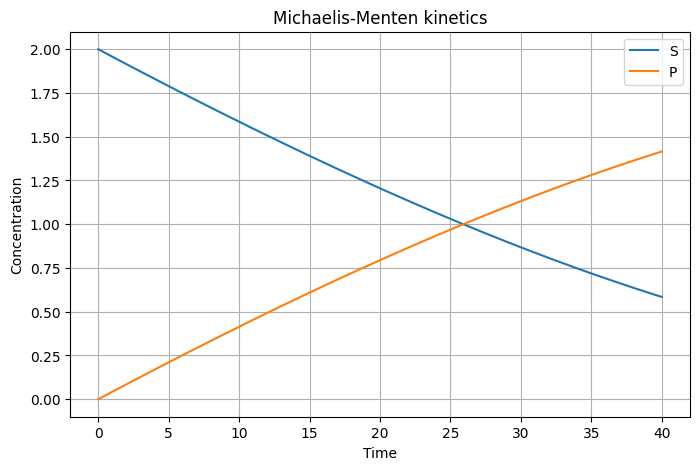

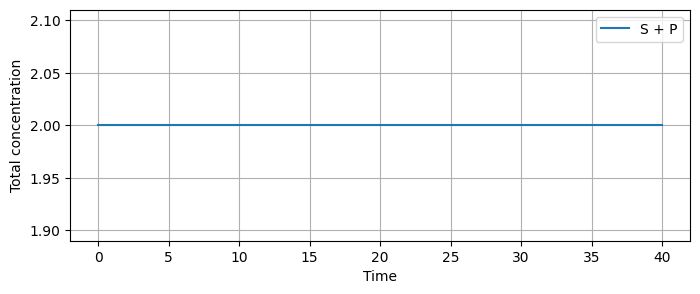

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def michaelis_menten_system(t, y, Vmax, Km):
    """
    Michaelis-Menten kinetics.

    S -> P
    """

    S, P = y

    v = Vmax * S / (Km + S)

    dS = -v
    dP =  v

    return [dS, dP]

k1  = 1.0
km1 = 0.5
k2  = 0.3
Etot = 0.2

Vmax = k2 * Etot
Km = (km1 + k2) / k1

Vmax = 0.06
Km = 0.80

S0 = 2.0
P0 = 0.0

y0 = [S0, P0]

t = np.linspace(0, 40, 500)

solution = solve_ivp(
    michaelis_menten_system,
    (0, 40),
    y0,
    args=(Vmax, Km),
    t_eval=t
)

S = solution.y[0]
P = solution.y[1]

plt.figure(figsize=(8,5))

plt.plot(t, S, label="S")
plt.plot(t, P, label="P")

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Michaelis-Menten kinetics")

plt.grid(True)
plt.legend()

plt.show()

plt.figure(figsize=(8,3))

plt.plot(t, S + P, label="S + P")

plt.xlabel("Time")
plt.ylabel("Total concentration")

plt.grid(True)
plt.legend()

plt.show()